# Замер метрики IoU на реальных данных

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import ripser
import persim
from sklearn.decomposition import PCA
from scipy.spatial.distance import pdist, squareform
import gudhi as gd
from gudhi.representations import Landscape, Silhouette, PersistenceImage
import tadasets
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import networkx as nx
import nibabel as nib
import os
from tqdm import tqdm
from skimage.transform import resize
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc, roc_curve
import warnings
import time
from sklearn.neighbors import NearestNeighbors
from scipy.linalg import svd
import pydicom
from pathlib import Path
from PIL import Image
import glob
warnings.filterwarnings("ignore", category=UserWarning)

target_shape = (128, 128, 64)

In [2]:
!pip install pydicom

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 5.6 MB/s eta 0:00:0000:0100:01

[notice] A new release of pip is available: 23.1.2 -> 25.0.1
[notice] To update, run: pip install --upgrade pip


In [ ]:
def load_and_display_sample_case(base_path, case_id=None):
    """
    Загружает и отображает один срез из всех четырех модальностей одного случая.
    
    Args:
        base_path: Путь к директории с данными (train или validation)
        case_id: ID случая для загрузки (если None, будет выбран первый доступный)
        
    Returns:
        Словарь с загруженными данными
    """
    if case_id is None:
        case_dirs = sorted([d for d in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, d))])
        if not case_dirs:
            raise ValueError(f"Не найдено директорий с случаями в {base_path}")
        case_id = case_dirs[0]
    
    case_path = os.path.join(base_path, case_id)
    print(f"Загрузка случая {case_id} из {case_path}")
    
    modalities = ['FLAIR', 'T1w', 'T1wCE', 'T2w']
    
    case_data = {}
    
    # Загружаем каждую модальность
    for modality in modalities:
        modality_path = os.path.join(case_path, modality)
        
        if not os.path.exists(modality_path):
            print(f"Предупреждение: директория {modality_path} не найдена")
            continue
        
        # Получаем список всех DICOM файлов в директории
        dicom_files = sorted([f for f in os.listdir(modality_path) if f.endswith('.dcm')])
        
        if not dicom_files:
            print(f"Предупреждение: не найдено DICOM файлов в {modality_path}")
            continue
        
        # Загружаем средний срез для демонстрации
        middle_slice_idx = len(dicom_files) // 2
        middle_slice_path = os.path.join(modality_path, dicom_files[middle_slice_idx])
        
        try:
            dicom_data = pydicom.dcmread(middle_slice_path)
            pixel_array = dicom_data.pixel_array
            
            # Нормализуем для отображения
            if pixel_array.max() > 0:
                pixel_array = pixel_array / pixel_array.max()
            
            case_data[modality] = {
                'pixel_array': pixel_array,
                'dicom_data': dicom_data
            }
            
            print(f"Загружен срез {middle_slice_idx+1}/{len(dicom_files)} для модальности {modality}")
            print(f"Размер изображения: {pixel_array.shape}")
            
        except Exception as e:
            print(f"Ошибка при загрузке {middle_slice_path}: {e}")
    
    # Отображаем все модальности
    if case_data:
        plt.figure(figsize=(16, 4))
        
        for i, modality in enumerate(modalities):
            if modality in case_data:
                plt.subplot(1, 4, i+1)
                plt.imshow(case_data[modality]['pixel_array'], cmap='gray')
                plt.title(f"{modality}")
                plt.axis('off')
        
        plt.tight_layout()
        plt.suptitle(f"Случай {case_id} - Средние срезы", fontsize=16)
        plt.subplots_adjust(top=0.85)
        plt.savefig(f"case_{case_id}_sample.png", dpi=300, bbox_inches='tight')
        plt.show()
    else:
        print("Не удалось загрузить данные для отображения")
    
    return case_data

def read_labels(labels_path):
    """
    Считывает файл с метками MGMT_value.
    
    Args:
        labels_path: Путь к CSV файлу с метками
        
    Returns:
        Словарь {case_id: MGMT_value}
    """
    import pandas as pd
    labels_df = pd.read_csv(labels_path)
    labels = dict(zip(labels_df['BraTS21ID'].astype(str).str.zfill(5), labels_df['MGMT_value']))
    print(f"Загружено {len(labels)} меток")
    return labels


===== Загрузка снимка 1 =====
Загрузка случая 00000 из ./data/00000
Загружен срез 201/400 для модальности FLAIR
Размер изображения: (512, 512)
Загружен срез 17/33 для модальности T1w
Размер изображения: (512, 512)
Загружен срез 65/129 для модальности T1wCE
Размер изображения: (512, 512)
Загружен срез 205/408 для модальности T2w
Размер изображения: (512, 512)


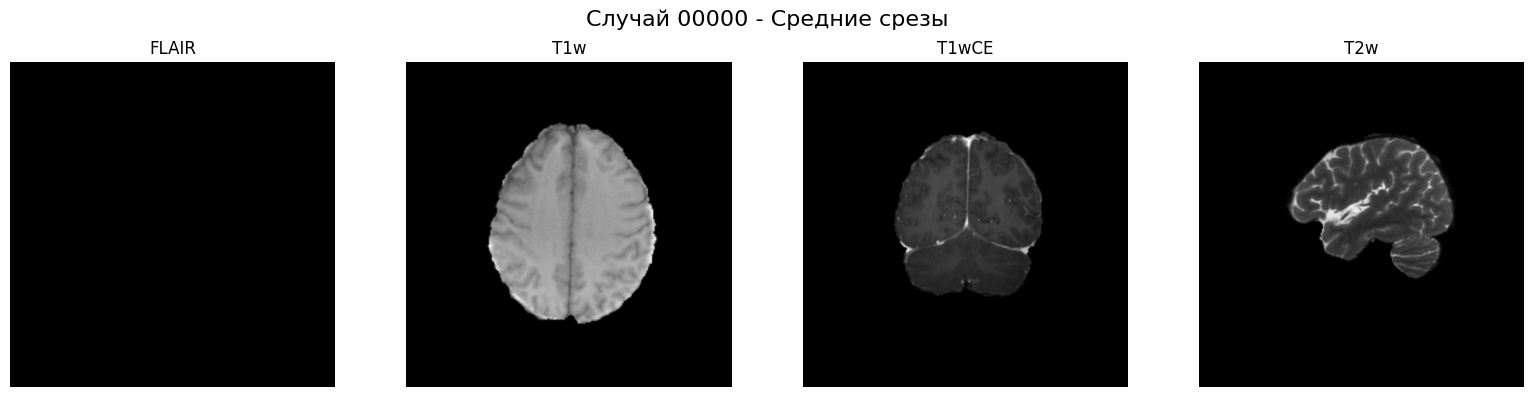

Загружено 585 меток
MGMT статус для случая 00000: 1

===== Загрузка снимка 2 =====
Загрузка случая 00002 из ./data/00002
Загружен срез 65/129 для модальности FLAIR
Размер изображения: (512, 512)
Загружен срез 16/31 для модальности T1w
Размер изображения: (512, 512)
Загружен срез 65/129 для модальности T1wCE
Размер изображения: (512, 512)
Загружен срез 193/384 для модальности T2w
Размер изображения: (512, 512)


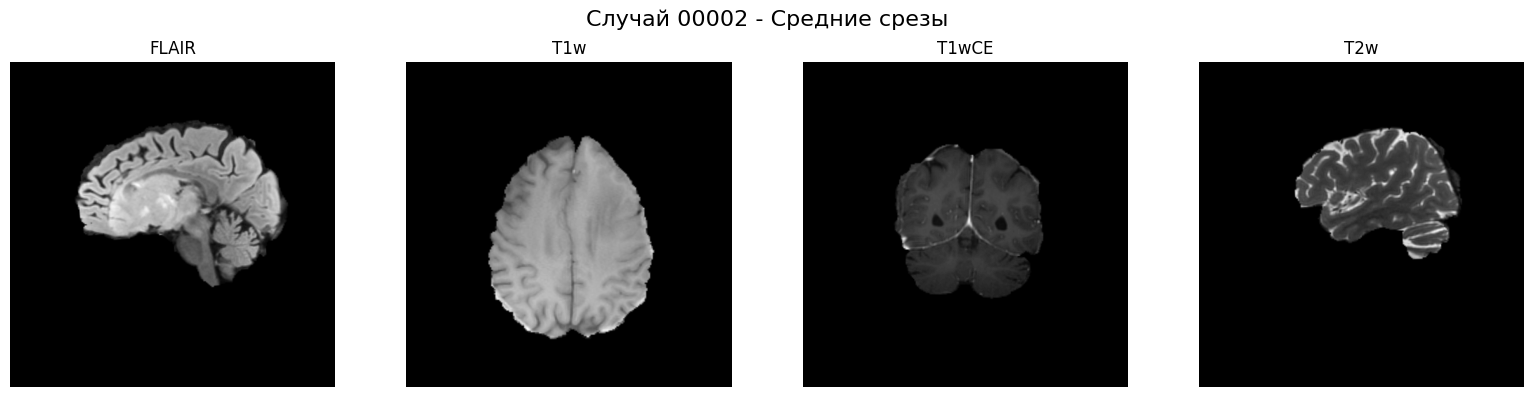

Загружено 585 меток
MGMT статус для случая 00002: 1

===== Загрузка снимка 3 =====
Загрузка случая 00003 из ./data/00003
Загружен срез 65/129 для модальности FLAIR
Размер изображения: (512, 512)
Загружен срез 17/33 для модальности T1w
Размер изображения: (512, 512)
Загружен срез 65/129 для модальности T1wCE
Размер изображения: (512, 512)
Загружен срез 205/408 для модальности T2w
Размер изображения: (512, 512)


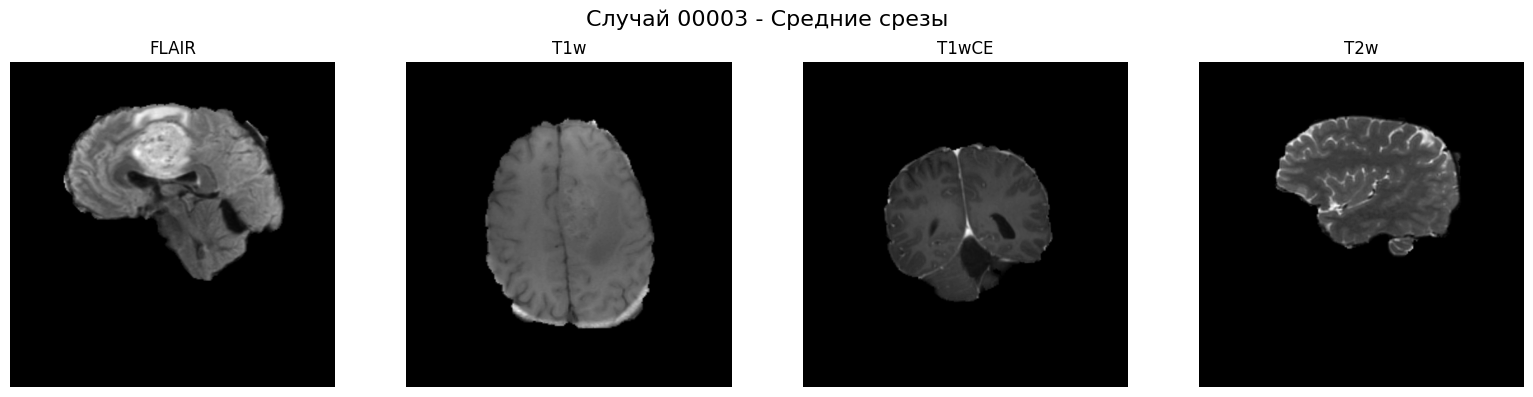

Загружено 585 меток
MGMT статус для случая 00003: 0


In [7]:
if __name__ == "__main__":
    base_path = "./data"
    
    for i in range(3):
        print(f"\n===== Загрузка снимка {i+1} =====")
        case_dirs = sorted([d for d in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, d))])
        
        if not case_dirs:
            print(f"Не найдено директорий с случаями в {base_path}")
            break
    
        case_id = case_dirs[i] if i < len(case_dirs) else case_dirs[0]
        case_data = load_and_display_sample_case(base_path, case_id)
        
        try:
            labels = read_labels("train_labels.csv")
            if case_id in labels:
                print(f"MGMT статус для случая {case_id}: {labels[case_id]}")
        except Exception as e:
            print(f"Не удалось загрузить метки: {e}")


# Маски сегментации

Найдено 51 файлов с опухолями и 51 файлов с масками
Первые 3 файлов опухолей: ['TCGA_CS_4941_19960909_11.tif', 'TCGA_CS_4941_19960909_14.tif', 'TCGA_CS_4943_20000902_13.tif']
Первые 3 файлов масок: ['TCGA_CS_4941_19960909_11_mask.tif', 'TCGA_CS_4941_19960909_14_mask.tif', 'TCGA_CS_4943_20000902_13_mask.tif']
Загружен снимок 1: TCGA_CS_4941_19960909_11.tif
Размер снимка опухоли: (256, 256, 3)
Размер маски: (256, 256)
Загружен снимок 2: TCGA_CS_4941_19960909_14.tif
Размер снимка опухоли: (256, 256, 3)
Размер маски: (256, 256)
Загружен снимок 3: TCGA_CS_4943_20000902_13.tif
Размер снимка опухоли: (256, 256, 3)
Размер маски: (256, 256)


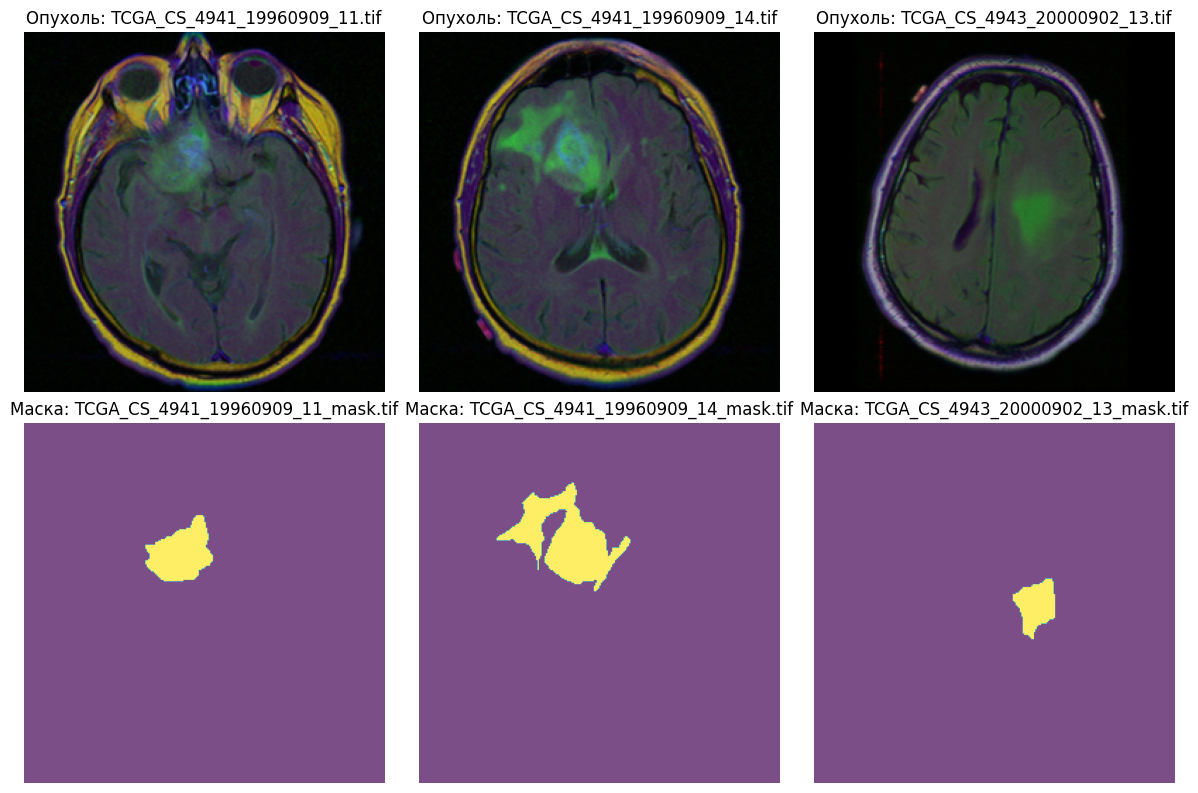

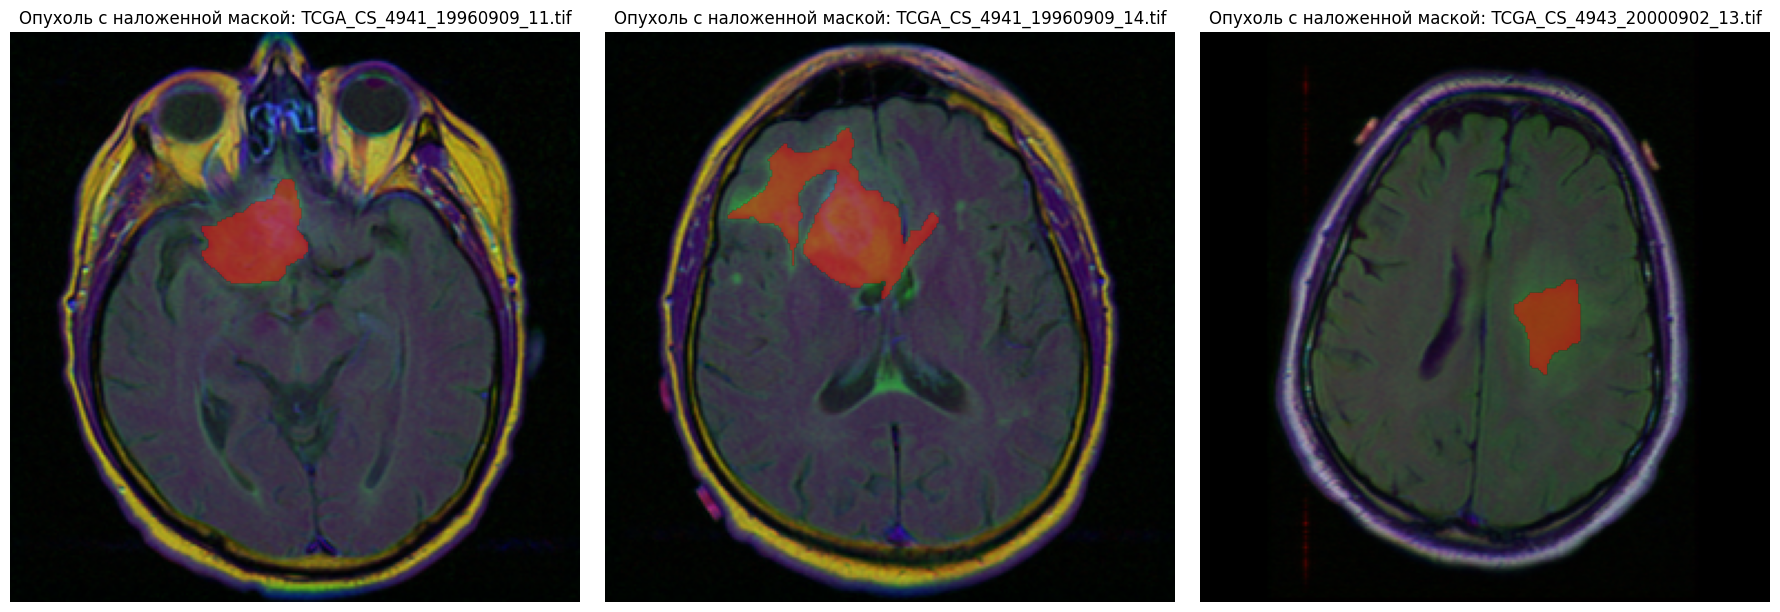

In [ ]:
def load_and_display_custom_dataset(base_path, num_samples=3):
    """
    Загружает и отображает пары снимков (опухоль и маска) из папок Tumor и Mask.
    
    Args:
        base_path: Путь к директории brain_tumor_custom
        num_samples: Количество пар снимков для отображения
    
    Returns:
        Словарь с загруженными изображениями
    """
    if not os.path.exists(base_path):
        raise ValueError(f"Директория {base_path} не существует")
    
    tumor_dir = os.path.join(base_path, "Tumor")
    mask_dir = os.path.join(base_path, "Mask")
    
    if not os.path.exists(tumor_dir) or not os.path.exists(mask_dir):
        raise ValueError(f"Директории Tumor или Mask не найдены в {base_path}")
    
    tumor_files = sorted(glob.glob(os.path.join(tumor_dir, "*.tif")))
    mask_files = sorted(glob.glob(os.path.join(mask_dir, "*.tif")))
    
    if not tumor_files or not mask_files:
        raise ValueError(f"TIF файлы не найдены в директориях {tumor_dir} или {mask_dir}")
    
    print(f"Найдено {len(tumor_files)} файлов с опухолями и {len(mask_files)} файлов с масками")
    
    tumor_files = tumor_files[:num_samples]
    mask_files = mask_files[:num_samples]
    
    tumor_basenames = [os.path.basename(f) for f in tumor_files]
    mask_basenames = [os.path.basename(f) for f in mask_files]
    
    print(f"Первые {num_samples} файлов опухолей: {tumor_basenames}")
    print(f"Первые {num_samples} файлов масок: {mask_basenames}")
    
    loaded_images = {}
    
    for i, (tumor_file, mask_file) in enumerate(zip(tumor_files, mask_files)):
        try:
            tumor_image = np.array(Image.open(tumor_file))
            mask_image = np.array(Image.open(mask_file))
            
            tumor_basename = os.path.basename(tumor_file)
            mask_basename = os.path.basename(mask_file)
            
            print(f"Загружен снимок {i+1}: {tumor_basename}")
            print(f"Размер снимка опухоли: {tumor_image.shape}")
            print(f"Размер маски: {mask_image.shape}")
            
            loaded_images[i] = {
                'tumor': {
                    'image': tumor_image,
                    'filename': tumor_basename
                },
                'mask': {
                    'image': mask_image,
                    'filename': mask_basename
                }
            }
            
        except Exception as e:
            print(f"Ошибка при загрузке файлов {tumor_file} или {mask_file}: {e}")
    
    visualize_tumor_and_masks(loaded_images)
    
    return loaded_images

def visualize_tumor_and_masks(loaded_images):
    """
    Визуализирует пары снимков (опухоль и маска).
    
    Args:
        loaded_images: Словарь с загруженными изображениями
    """
    if not loaded_images:
        print("Нет данных для визуализации.")
        return
    
    n_samples = len(loaded_images)
    plt.figure(figsize=(4*n_samples, 8))
    
    for i, (idx, img_data) in enumerate(loaded_images.items()):
        tumor_image = img_data['tumor']['image']
        tumor_filename = img_data['tumor']['filename']
        
        mask_image = img_data['mask']['image']
        mask_filename = img_data['mask']['filename']
        
        plt.subplot(2, n_samples, i+1)
        
        # Проверяем, цветное ли изображение
        if len(tumor_image.shape) == 3 and tumor_image.shape[2] == 3:
            plt.imshow(tumor_image)
        else:
            plt.imshow(tumor_image, cmap='gray')
            
        plt.title(f"Опухоль: {tumor_filename}")
        plt.axis('off')
        plt.subplot(2, n_samples, i+1+n_samples)
        
        if mask_image.dtype == bool or np.array_equal(np.unique(mask_image), [0, 1]):
            plt.imshow(mask_image, cmap='binary', alpha=0.7)
        elif len(np.unique(mask_image)) <= 4:
            plt.imshow(mask_image, cmap='viridis', alpha=0.7)
        else:
            if len(mask_image.shape) == 3 and mask_image.shape[2] == 3:
                plt.imshow(mask_image)
            else:
                plt.imshow(mask_image, cmap='gray')
            
        plt.title(f"Маска: {mask_filename}")
        plt.axis('off')
    
    plt.tight_layout()
    plt.savefig("tumor_and_masks.png", dpi=300, bbox_inches='tight')
    plt.show()

def visualize_overlay(loaded_images):
    """
    Визуализирует наложение маски на оригинальное изображение.
    
    Args:
        loaded_images: Словарь с загруженными изображениями
    """
    if not loaded_images:
        print("Нет данных для визуализации.")
        return
    
    n_samples = len(loaded_images)
    plt.figure(figsize=(6*n_samples, 6))
    
    for i, (idx, img_data) in enumerate(loaded_images.items()):
        tumor_image = img_data['tumor']['image']
        tumor_filename = img_data['tumor']['filename']
        
        mask_image = img_data['mask']['image']
        
        plt.subplot(1, n_samples, i+1)
        
        if len(tumor_image.shape) == 3 and tumor_image.shape[2] == 3:
            plt.imshow(tumor_image)
        else:
            plt.imshow(tumor_image, cmap='gray')
        
        if not np.array_equal(np.unique(mask_image), [0, 1]) and mask_image.dtype != bool:
            binary_mask = mask_image > 0
        else:
            binary_mask = mask_image.astype(bool)
        
        mask_overlay = np.zeros((*binary_mask.shape, 4))
        mask_overlay[binary_mask] = [1, 0, 0, 0.5]  # Красный цвет с прозрачностью
        
        plt.imshow(mask_overlay)
        plt.title(f"Опухоль с наложенной маской: {tumor_filename}")
        plt.axis('off')
    
    plt.tight_layout()
    plt.savefig("tumor_mask_overlay.png", dpi=300, bbox_inches='tight')
    plt.show()

if __name__ == "__main__":
    base_path = "brain_tumor_custom"
    
    try:
        loaded_images = load_and_display_custom_dataset(base_path, num_samples=3)
        visualize_overlay(loaded_images)
        
    except Exception as e:
        print(f"Произошла ошибка: {e}")
